# 4 — Walk-Forward Evaluation & Results

This notebook runs a proper walk-forward cross-validation
(the gold standard for time-series evaluation) and generates
all result plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath("../src"))

import warnings
warnings.filterwarnings('ignore')

from pjm_spike_forecast.data import build_demo_dataset, load_lmp, load_weather, merge_lmp_weather
from pjm_spike_forecast.features import build_feature_matrix, get_feature_columns
from pjm_spike_forecast.config import BacktestConfig
from pjm_spike_forecast.evaluation import run_walk_forward_cv, summarise_cv_results
from pjm_spike_forecast.visualization import *

lmp = load_lmp("../data/raw/nyiso_lmp.csv")
weather = load_weather("../data/raw/weather.csv")
df = merge_lmp_weather(lmp, weather)
# df = build_demo_dataset(n_days=365, seed=42)
feat_df = build_feature_matrix(df)
feature_cols = get_feature_columns(feat_df)

## 4.1 — Walk-Forward Cross-Validation

In [2]:
cfg = BacktestConfig(n_splits=4, train_months=2, test_months=1, gap_hours=24)

# Baseline
bl_results = run_walk_forward_cv(feat_df, feature_cols, cfg=cfg, model_type="baseline")
bl_summary = summarise_cv_results(bl_results)

# LightGBM
lgbm_results = run_walk_forward_cv(feat_df, feature_cols, cfg=cfg, model_type="lgbm")
lgbm_summary = summarise_cv_results(lgbm_results)

print("\n=== Baseline CV Summary ===")
print(bl_summary[["fold", "clf_f1", "clf_precision", "clf_recall", "reg_rmse", "reg_mae"]].to_string(index=False))
print(f"\nMean Spike F1: {bl_summary['clf_f1'].mean():.3f}")
print(f"Mean Price RMSE: {bl_summary['reg_rmse'].mean():.2f}")

print("\n=== LightGBM CV Summary ===")
print(lgbm_summary[["fold", "clf_f1", "clf_precision", "clf_recall", "reg_rmse", "reg_mae"]].to_string(index=False))
print(f"\nMean Spike F1: {lgbm_summary['clf_f1'].mean():.3f}")
print(f"Mean Price RMSE: {lgbm_summary['reg_rmse'].mean():.2f}")


=== Baseline CV Summary ===
 fold  clf_f1  clf_precision  clf_recall  reg_rmse   reg_mae
    0     0.0            0.0         0.0 76.228776 62.341688
    1     0.0            0.0         0.0 24.273970 17.835546
    2     0.0            0.0         0.0 36.362430 23.369014
    3     0.0            0.0         0.0 45.716331 20.542268

Mean Spike F1: 0.000
Mean Price RMSE: 45.65

=== LightGBM CV Summary ===
 fold   clf_f1  clf_precision  clf_recall  reg_rmse   reg_mae
    0 0.131148       0.800000    0.071429 29.588653 13.723127
    1 0.358209       0.428571    0.307692 12.352842  8.103670
    2 0.252874       0.282051    0.229167 21.510529 12.128645
    3 0.476190       0.625000    0.384615 34.993575 11.411469

Mean Spike F1: 0.305
Mean Price RMSE: 24.61


## 4.2 — Per-Fold Metric Plots

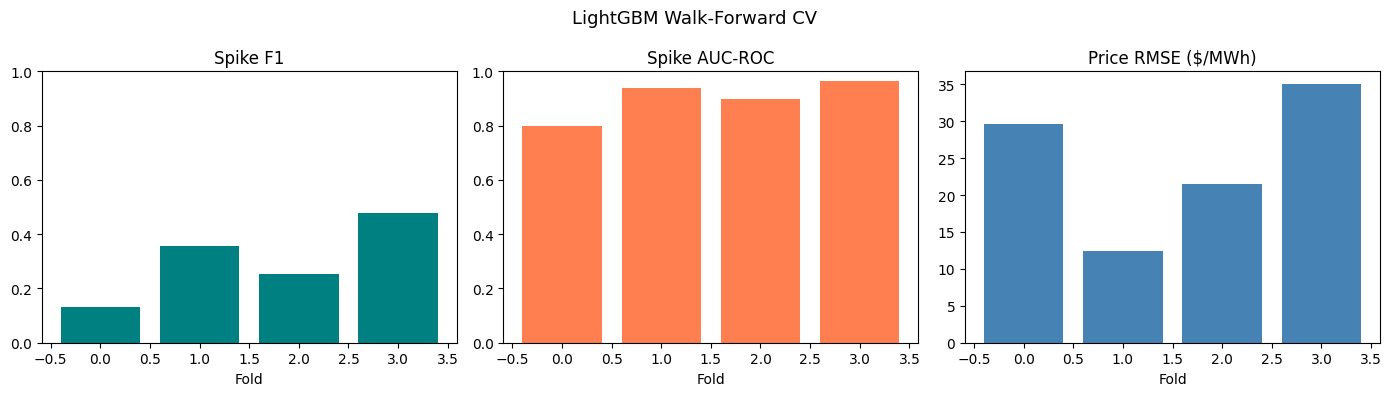

In [3]:
fig = plot_cv_summary(lgbm_results, title="LightGBM Walk-Forward CV")
plt.show()

## 4.3 — Final Model Results

Train on 80% (temporal), test on remaining 20%.

In [4]:
from pjm_spike_forecast.models import SpikeClassifier, PriceRegressor, HourlyBaseline
from pjm_spike_forecast.evaluation import classification_metrics, regression_metrics

split = int(len(feat_df) * 0.8)
train, test = feat_df.iloc[:split], feat_df.iloc[split:]
X_train, X_test = train[feature_cols], test[feature_cols]

clf = SpikeClassifier()
clf.fit(X_train, train["spike"])
spike_pred = clf.predict(X_test)
spike_proba = clf.predict_proba(X_test)

reg = PriceRegressor()
reg.fit(X_train, train["lmp"])
price_pred = reg.predict(X_test)

clf_m = classification_metrics(test["spike"].values, spike_pred, spike_proba)
reg_m = regression_metrics(test["lmp"].values, price_pred)

print("=== Final Test Metrics ===")
print(f"Spike Precision: {clf_m['precision']:.3f}")
print(f"Spike Recall:    {clf_m['recall']:.3f}")
print(f"Spike F1:        {clf_m['f1']:.3f}")
print(f"Spike AUC-ROC:   {clf_m.get('auc_roc', 0):.3f}")
print(f"\nPrice RMSE:      {reg_m['rmse']:.2f} $/MWh")
print(f"Price MAE:       {reg_m['mae']:.2f} $/MWh")
print(f"Price R²:        {reg_m['r2']:.3f}")

=== Final Test Metrics ===
Spike Precision: 0.488
Spike Recall:    0.728
Spike F1:        0.584
Spike AUC-ROC:   0.970

Price RMSE:      17.20 $/MWh
Price MAE:       6.48 $/MWh
Price R²:        0.768


## 4.4 — Result Plots

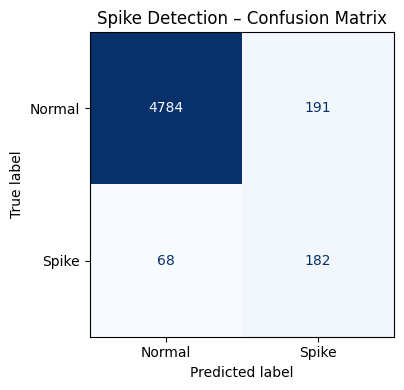

In [5]:
# Confusion matrix
fig = plot_confusion_matrix(test["spike"].values, spike_pred)
plt.show()

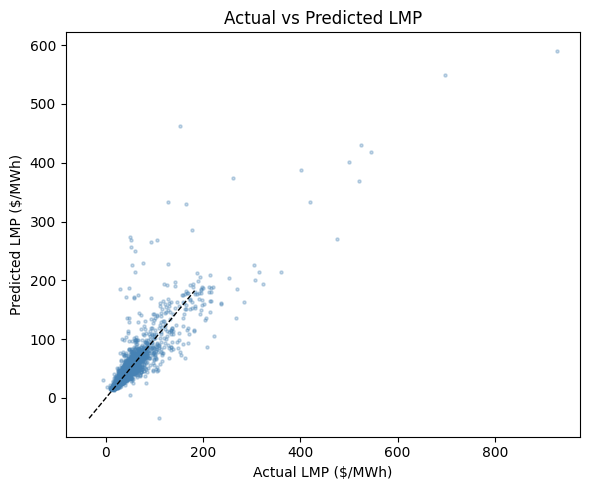

In [6]:
# Actual vs predicted LMP
fig = plot_actual_vs_predicted(test["lmp"].values, price_pred)
plt.show()

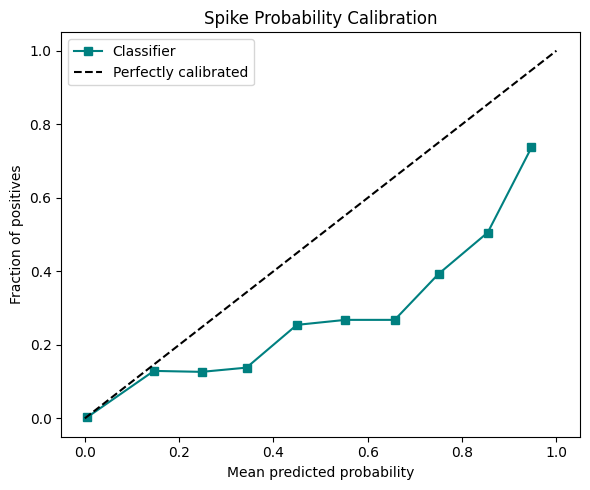

In [7]:
# Calibration curve
fig = plot_calibration_curve(test["spike"].values, spike_proba)
plt.show()

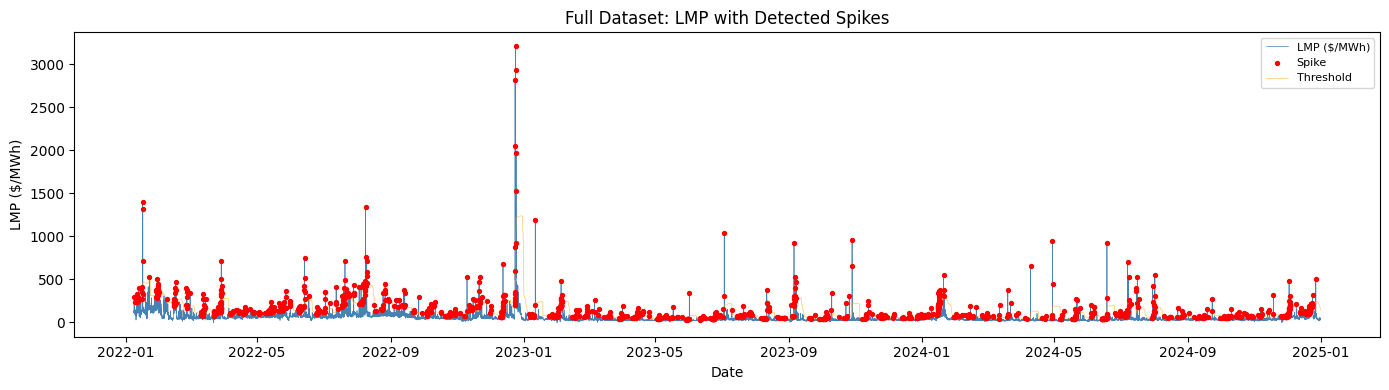

In [8]:
# LMP time series with spikes
fig = plot_lmp_timeseries(feat_df, title="Full Dataset: LMP with Detected Spikes")
plt.show()